<a href="https://colab.research.google.com/github/guslimaa777/45419370/blob/main/aula8_kmeans_industrial_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 8 – Agrupamento e identificação de padrões operacionais

## Versão do aluno

### Objetivo da aula
Aplicar o algoritmo **K-means** para identificar grupos de comportamento operacional em uma base de dados industrial.

### Instruções
Complete as células indicadas e registre suas interpretações ao longo da atividade.


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para leitura da base, visualização, padronização e agrupamento.


In [3]:
# Importe a biblioteca `pandas` utilizando o alias `pd` para manipulação e análise de tabelas e datasets.
# Importe a biblioteca `numpy` utilizando o alias `np` para realizar operações matemáticas e numéricas.
# Importe a biblioteca `matplotlib.pyplot` utilizando o alias `plt` para criação e exibição de gráficos.
# Importe a biblioteca `seaborn` utilizando o alias `sns` para criação de gráficos estatísticos e visualização dos dados.
# Importe a classe `StandardScaler` do módulo `sklearn.preprocessing` para padronizar as variáveis numéricas antes do agrupamento.
# Importe a classe `KMeans` do módulo `sklearn.cluster` para realizar o agrupamento dos dados em diferentes clusters.
# Importe a função `silhouette_score` do módulo `sklearn.metrics` para avaliar a qualidade dos agrupamentos gerados pelo algoritmo K-Means.
# Configure o pandas para exibir todas as colunas disponíveis do DataFrame durante a análise dos dados.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Leitura da base

Leia o arquivo `dados_aula8_kmeans_industrial.csv` e mostre as primeiras linhas.


In [4]:
# Utilize a função `read_csv` do pandas para carregar o arquivo CSV `dados_aula8_kmeans_industrial.csv` em um DataFrame chamado `df`.
# Utilize o método `head()` para visualizar as primeiras linhas do dataset e verificar se os dados foram carregados corretamente.

In [6]:
# Complete aqui
df = pd.read_csv('dados_aula8_kmeans_industrial.csv')
df.head()

,id_registro,linha,turno,produto,vazao_l_min,pressao_bar,temperatura_c,vibracao_mm_s,consumo_energia_kwh,tempo_resposta_s,erro_vazao_pct,leituras_invalidas,abertura_valvula_pct,estado_operacional_referencia
0,REG_0001,Linha_C,Manhã,Base,122.980285,3.520386,42.788341,1.338362,18.467412,1.492479,1.950425,0,53.539009,Estavel
1,REG_0002,Linha_C,Manhã,Solvente,119.170414,3.703415,40.919981,1.062157,19.379465,1.614617,1.596653,2,43.449158,Estavel
2,REG_0003,Linha_A,Noite,Acido,123.886131,3.352569,40.650675,1.311664,17.902116,NaN,1.895365,1,45.259073,Estavel
3,REG_0004,Linha_A,Tarde,Base,129.138179,3.431191,42.607915,4.203438,18.361541,1.560486,2.059482,1,55.716320,Estavel
4,REG_0005,Linha_B,Manhã,Acido,118.595080,3.417657,41.718437,1.105775,18.621130,1.436369,1.355104,0,52.854327,Estavel


## 3. Inspeção inicial

Verifique a dimensão da base, os tipos de dados, os valores faltantes e a quantidade de duplicatas.

**Registro técnico:**
- Quais colunas exigem tratamento?
- Há duplicatas?
- O que precisa ser ajustado antes de aplicar o K-means?


In [ ]:
# Utilize `df.shape` para verificar a dimensão do dataset, identificando a quantidade de linhas e colunas.
# Utilize `df.dtypes` para verificar o tipo de dado armazenado em cada coluna.
# Utilize `df.isna().sum()` para identificar a quantidade de valores ausentes em cada coluna.
# Utilize `df.duplicated().sum()` para verificar se existem registros duplicados no dataset.
# Analise os resultados para identificar possíveis problemas que precisam ser tratados antes da aplicação do modelo.

In [8]:
# Complete aqui
print('Dimensão da base:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nValores faltantes:')
print(df.isna().sum())
print('\nDuplicatas:', df.duplicated().sum())

Dimensão da base: (270, 14)

Tipos de dados:
id_registro                       object
linha                             object
turno                             object
produto                           object
vazao_l_min                      float64
pressao_bar                      float64
temperatura_c                    float64
vibracao_mm_s                    float64
consumo_energia_kwh              float64
tempo_resposta_s                 float64
erro_vazao_pct                   float64
leituras_invalidas                 int64
abertura_valvula_pct             float64
estado_operacional_referencia     object
dtype: object

Valores faltantes:
id_registro                      0
linha                            0
turno                            0
produto                          9
vazao_l_min                      0
pressao_bar                      8
temperatura_c                    9
vibracao_mm_s                    0
consumo_energia_kwh              0
tempo_resposta_s                

1- Quais colunas exigem tratamento — nulos, tipos incorretos, outliers, categóricas etc.

2- Se existem duplicatas — linhas totalmente duplicadas e possíveis duplicidades relevantes.

3- O que ajustar antes do K-means — seleção de variáveis, tratamento de nulos/outliers, codificação e principalmente padronização/normalização das variáveis numéricas.


## 4. Tratamento inicial

- Remova duplicatas.
- Trate valores faltantes numéricos com a mediana.
- Trate valores faltantes categóricos com a moda.


In [9]:
# Utilize o método `drop_duplicates()` do pandas para remover registros duplicados do DataFrame.
# Em seguida, utilize o método `copy()` para criar uma cópia independente do DataFrame após a remoção das duplicatas.

# Crie a lista `colunas_numericas` contendo os nomes das colunas que armazenam valores numéricos.
# Essa lista será utilizada para aplicar o mesmo tratamento de valores ausentes em todas as variáveis numéricas.

# Utilize um laço `for` para percorrer cada coluna armazenada na lista `colunas_numericas`.
# Para cada coluna, utilize o método `fillna()` para substituir os valores ausentes.
# Dentro do `fillna()`, utilize o método `median()` para calcular a mediana da respectiva coluna.
# A mediana será utilizada como valor de preenchimento porque é menos sensível à influência de valores extremos.

# Crie um segundo laço `for` para percorrer as colunas categóricas `linha`, `turno` e `produto`.
# Utilize novamente o método `fillna()` para substituir os valores ausentes dessas colunas.
# Utilize o método `mode()` para identificar o valor que aparece com maior frequência em cada coluna.
# Utilize `[0]` para selecionar o primeiro valor retornado pela função `mode()` e utilizá-lo como preenchimento.

# Utilize a propriedade `shape` do DataFrame para verificar sua dimensão após a limpeza.
# A propriedade `shape` retorna a quantidade de linhas e colunas existentes no DataFrame.

# Utilize o método `isna()` para identificar os valores ausentes existentes no DataFrame.
# Em seguida, utilize o método `sum()` para contabilizar a quantidade de valores ausentes em cada coluna.
# Analise o resultado para confirmar se o tratamento dos dados ausentes foi realizado corretamente.

In [12]:
# Complete aqui
df = df.drop_duplicates().copy()

colunas_numericas = [
    'vazao_l_min', 'pressao_bar', 'temperatura_c', 'vibracao_mm_s',
    'consumo_energia_kwh', 'tempo_resposta_s', 'erro_vazao_pct',
    'leituras_invalidas', 'abertura_valvula_pct'
]

for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

for col in ['linha', 'turno', 'produto']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isna().sum())

id_registro                      0
linha                            0
turno                            0
produto                          0
vazao_l_min                      0
pressao_bar                      0
temperatura_c                    0
vibracao_mm_s                    0
consumo_energia_kwh              0
tempo_resposta_s                 0
erro_vazao_pct                   0
leituras_invalidas               0
abertura_valvula_pct             0
estado_operacional_referencia    0
dtype: int64


## 5. Seleção das features

Monte a matriz `X` usando apenas as variáveis numéricas do processo.

**Pergunta:**  
Por que a coluna `estado_operacional_referencia` não deve ser usada como entrada do K-means?


In [13]:
# Crie o DataFrame `X` selecionando, por meio de `df[colunas_numericas]`, apenas as variáveis numéricas que serão utilizadas no K-Means.
# Utilize o método `copy()` para criar uma cópia independente dos dados selecionados.
# Utilize o método `head()` para visualizar as primeiras linhas de `X` e conferir os dados selecionados.

In [15]:
# Complete aqui
X = df[colunas_numericas].copy()
X.head()

,vazao_l_min,pressao_bar,temperatura_c,vibracao_mm_s,consumo_energia_kwh,tempo_resposta_s,erro_vazao_pct,leituras_invalidas,abertura_valvula_pct
0,122.980285,3.520386,42.788341,1.338362,18.467412,1.492479,1.950425,0,53.539009
1,119.170414,3.703415,40.919981,1.062157,19.379465,1.614617,1.596653,2,43.449158
2,123.886131,3.352569,40.650675,1.311664,17.902116,2.277365,1.895365,1,45.259073
3,129.138179,3.431191,42.607915,4.203438,18.361541,1.560486,2.059482,1,55.716320
4,118.595080,3.417657,41.718437,1.105775,18.621130,1.436369,1.355104,0,52.854327


**Resposta do aluno:**



## 6. Padronização

Padronize as variáveis com `StandardScaler`.

**Pergunta:**  
Por que a padronização é importante antes do K-means?


In [18]:
# Crie um objeto `StandardScaler()` para realizar a padronização das variáveis numéricas.
# Utilize o método `fit_transform()` para calcular os parâmetros de padronização e transformar os dados de `X`.
# Armazene os dados padronizados em `X_scaled`.
# Utilize `[:5]` para visualizar as cinco primeiras linhas dos dados padronizados.

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.10124033, -0.02549359, -0.30541223, -0.9049264 , -0.67284053,
        -0.99293185, -1.13693772, -1.58258215,  0.00458417],
       [-0.07246552,  0.23781817, -0.56331686, -1.16114478, -0.44789565,
        -0.87500152, -1.33454717, -0.50490956, -0.81799044],
       [ 0.14254115, -0.26692127, -0.60049133, -0.92969297, -0.81226271,
        -0.23508793, -1.16769297, -1.04374586, -0.67043722],
       [ 0.3820011 , -0.15381293, -0.33031783,  1.75282832, -0.69895218,
        -0.92726794, -1.07602036, -1.04374586,  0.18208939],
       [-0.0986971 , -0.1732829 , -0.45309966, -1.1206831 , -0.63492825,
        -1.04710804, -1.4694712 , -1.58258215, -0.05123447]])

**Resposta do aluno:**



## 7. Teste de valores de k

Calcule a inércia e o silhouette score para valores de `k` entre 2 e 7.


# 🔹 K-Means — Identificação de Perfis Operacionais

### Pergunta de negócio

**É possível identificar diferentes perfis de operação das máquinas
a partir de suas características de funcionamento?**

O objetivo é descobrir grupos de registros com comportamentos
semelhantes, sem informar previamente ao algoritmo quais são esses grupos.

O K-Means irá testar diferentes quantidades de grupos (K) e utilizaremos
a **Inércia** e o **Silhouette Score** para auxiliar na escolha do número
de clusters e descobrir uma boa divisão dos dados

In [ ]:
# Crie uma lista vazia chamada `inercias`.
# Crie uma lista vazia chamada `silhuetas`.
# Crie `k_range` utilizando `range(2, 8)` para gerar os valores de `k` de 2 até 7.
# Percorra os valores de `k_range` utilizando um laço `for`.
# Para cada valor de `k`, crie um modelo `KMeans` definindo `n_clusters=k`, `random_state=42` e `n_init=10`.
# Utilize o método `fit_predict()` do modelo para treinar o K-Means com os dados `X_scaled` e armazenar os grupos em `grupos_temp`.
# Utilize a propriedade `inertia_` do modelo e adicione seu valor à lista `inercias` com o método `append()`.
# Utilize a função `silhouette_score()` com `X_scaled` e `grupos_temp` e adicione o resultado à lista `silhuetas` com o método `append()`.
# Crie o DataFrame `resultados_k` utilizando `pd.DataFrame()`.
# Crie a coluna `k` utilizando `list(k_range)`.
# Crie a coluna `inercia` utilizando a lista `inercias`.
# Crie a coluna `silhouette` utilizando a lista `silhuetas`.
# Exiba o DataFrame `resultados_k`.

In [21]:
# Complete aqui

inercias = []
silhuetas = []
k_range = range(2, 8)

for k in k_range:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupos_temp = modelo_temp.fit_predict(X_scaled)
    inercias.append(modelo_temp.inertia_)
    silhuetas.append(silhouette_score(X_scaled, grupos_temp))

resultados_k = pd.DataFrame({
    'k': list(k_range),
    'inercia': inercias,
    'silhouette': silhuetas
})

resultados_k

,k,inercia,silhouette
0,2,1171.970379,0.535022
1,3,460.166777,0.660713
2,4,377.675108,0.669010
3,5,326.773598,0.672361
4,6,310.934186,0.510906
5,7,278.327373,0.557876


### Explicando `k_range = range(2,8)`:

* K=0 → K-Means não pode ter zero clusters.
* K=1 → Não é adequado para calcular o Silhouette Score, pois é necessário ter pelo menos 2 grupos.

In [ ]:
# Crie uma nova figura usando `plt.figure()` com tamanho `figsize=(8, 4)`.

# Crie um gráfico de linha usando `plt.plot()`.
# Utilize `resultados_k['k']` no eixo X, representando o número de clusters.
# Utilize `resultados_k['inercia']` no eixo Y, representando a inércia.
# Utilize `marker='o'` para marcar cada ponto da linha.

# Defina o título do gráfico com `plt.title()`: 'Método do cotovelo'.

# Defina o nome do eixo X usando `plt.xlabel()`: 'Número de clusters (k)'.

# Defina o nome do eixo Y usando `plt.ylabel()`: 'Inércia'.

# Exiba o gráfico utilizando `plt.show()`.


# Crie uma segunda figura usando `plt.figure()` com tamanho `figsize=(8, 4)`.

# Crie um gráfico de linha usando `plt.plot()`.
# Utilize `resultados_k['k']` no eixo X, representando o número de clusters.
# Utilize `resultados_k['silhouette']` no eixo Y, representando o Silhouette Score.
# Utilize `marker='o'` para marcar cada ponto da linha.

# Defina o título do gráfico com `plt.title()`: 'Silhouette score por número de clusters'.

# Defina o nome do eixo X usando `plt.xlabel()`: 'Número de clusters (k)'.

# Defina o nome do eixo Y usando `plt.ylabel()`: 'Silhouette'.

# Exiba o gráfico utilizando `plt.show()`.

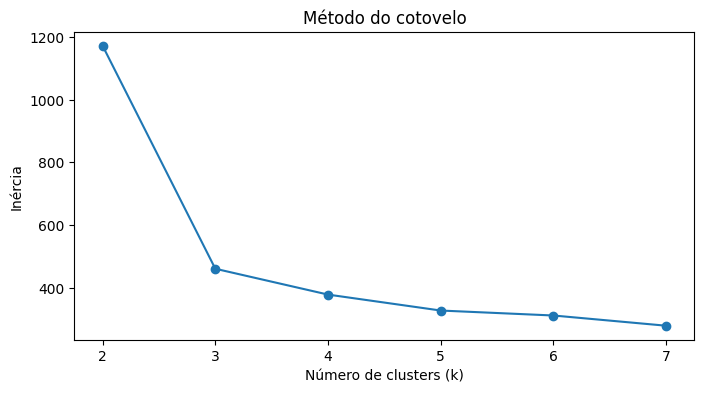

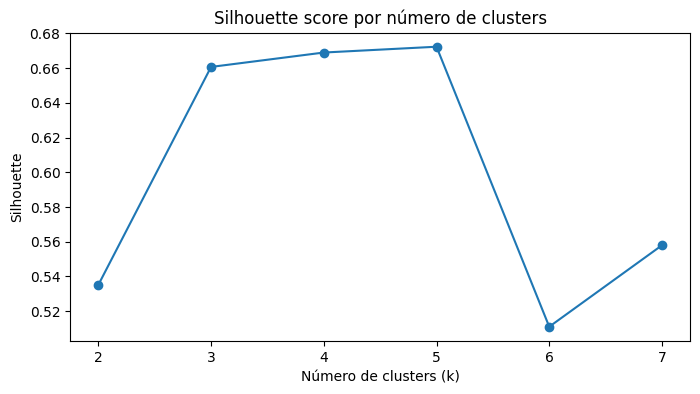

In [22]:
# Gere os gráficos aqui
plt.figure(figsize=(8,4))

plt.plot(resultados_k['k'], resultados_k['inercia'], marker='o')
plt.title('Método do cotovelo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(resultados_k['k'], resultados_k['silhouette'], marker='o')
plt.title('Silhouette score por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette')
plt.show()

### ***Explicando o teste***

>Não existe uma inércia ideal ou um valor mínimo universal.<br/>
>No K-Means, a inércia sempre diminui quando aumentamos o número de clusters. Por isso, não basta escolher o menor valor.

***cotovelo*** é o ponto em que aumentar K deixa de trazer uma redução significativa da inércia.

> "O teste indica que os dados possuem uma estrutura de agrupamento razoavelmente bem definida, principalmente entre 3 e 5 grupos. O próximo passo é analisar os clusters para entender o significado operacional de cada grupo."

### Inércia
> Inércia = soma das distâncias quadráticas de cada registro até o centróide do seu cluster.
> O Centroide é a media aritimetica do grupo, e depois obtem a soma das distâncias euclidianas ao quadrado de cada registro até o centróide do seu cluster.

### Silhueta
 > O quão bem o registro se encaixa no seu grupo e se separa dos demais.

## 8. Escolha do número de clusters

Escolha um valor de `k` e justifique sua decisão com base nos resultados.


**Justificativa do aluno:**



## 9. Criação do modelo K-means

Crie o modelo com o valor de `k` escolhido, ajuste aos dados padronizados e gere os clusters.


In [ ]:
# Crie o modelo `KMeans` definindo n_clusters=`3`, `random_state=42` e `n_init=10`.
# Utilize o método `fit_predict()` com `X_scaled` para treinar o modelo e obter o cluster de cada registro.
# Armazene os grupos gerados na variável `clusters`.
# Crie a coluna `cluster` no DataFrame `df` e atribua os grupos armazenados em `clusters`.
# Selecione as colunas `id_registro` e `cluster` do DataFrame e utilize o método `head()` para visualizar os primeiros registros.

In [23]:
# Complete aqui
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters
df[['id_registro', 'cluster']].head()

,id_registro,cluster
0,REG_0001,2
1,REG_0002,2
2,REG_0003,2
3,REG_0004,2
4,REG_0005,2


## 10. Interpretação dos clusters

Calcule a média das variáveis numéricas por cluster e interprete o perfil de cada grupo e responda.

* qual grupo tem maior vibração; <br/>
* qual grupo parece mais estável; <br/>
* qual grupo apresenta maior erro ou maior tempo de resposta.

In [25]:
# Agrupe o DataFrame `df` pela coluna `cluster` utilizando o método `groupby()`.
# Selecione as colunas numéricas definidas em `colunas_numericas`.
# Calcule a média de cada variável numérica dentro de cada cluster utilizando o método `mean()`.
# Arredonde os resultados para 2 casas decimais utilizando o método `round(2)`.
# Armazene o resultado na variável `perfil_clusters`.
# Exiba `perfil_clusters` para visualizar o perfil médio de cada cluster.

In [32]:
from pandas.core import groupby
# Complete aqui
perfil_clusters = df.groupby('cluster')[colunas_numericas].mean().round(2)
perfil_clusters

,vazao_l_min,pressao_bar,temperatura_c,vibracao_mm_s,consumo_energia_kwh,tempo_resposta_s,erro_vazao_pct,leituras_invalidas,abertura_valvula_pct
cluster,,,,,,,,,
0,146.93,4.34,54.50,2.25,25.30,2.37,4.28,3.04,67.84
1,94.85,2.73,38.39,3.52,20.34,3.76,6.04,4.94,40.14
2,119.41,3.51,41.96,1.27,18.05,1.53,1.83,1.00,51.95


In [ ]:
# Utilize a coluna `cluster` do DataFrame `df`.
# Utilize o método `value_counts()` para contar a quantidade de registros pertencentes a cada cluster.
# Utilize o método `sort_index()` para ordenar os clusters pelo seu índice.
# Exiba o resultado para verificar a quantidade de registros em cada cluster.

In [37]:
df['cluster'].sort_index().sort_index()

,cluster
0,2
1,2
2,2
3,2
4,2
...,...
265,0
266,2
267,0
268,2


**Interpretação do aluno:**
- Cluster 0:
- Cluster 1:
- Cluster 2:


## 11. Visualização dos agrupamentos

Crie um gráfico de dispersão com duas variáveis importantes do processo e use a cor para distinguir os clusters.


In [35]:
# Crie uma figura com tamanho 8x6 utilizando `plt.figure(figsize=(8,6))`.
# Crie um gráfico de dispersão utilizando `sns.scatterplot()`.
# Utilize o DataFrame `df` como fonte dos dados por meio do parâmetro `data`.
# Defina `vazao_l_min` como variável do eixo X utilizando `x`.
# Defina `vibracao_mm_s` como variável do eixo Y utilizando `y`.
# Utilize `cluster` em `hue` para diferenciar os clusters por cores.
# Utilize `cluster` em `style` para diferenciar os clusters também pelos símbolos dos pontos.
# Defina o tamanho dos pontos como 80 utilizando `s`.
# Defina o título do gráfico como `Clusters observados em vazão x vibração` utilizando `plt.title()`.
# Exiba o gráfico utilizando `plt.show()`.

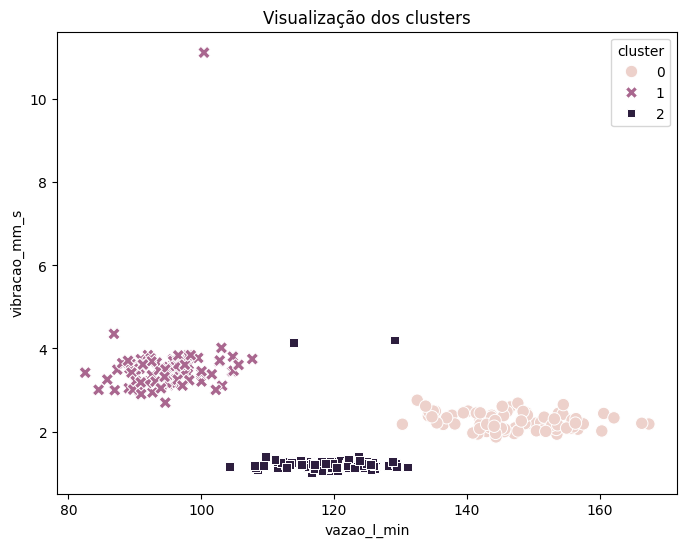

In [38]:
# Complete aqui
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='vazao_l_min',
    y='vibracao_mm_s',
    hue='cluster',
    style='cluster',
    s=80
)
plt.title('Visualização dos clusters')
plt.show()

## 12. Comparação com a coluna de referência

Monte uma tabela cruzada entre `cluster` e `estado_operacional_referencia`.

**Pergunta:**  
Os agrupamentos encontrados se aproximam de padrões operacionais reconhecíveis?


In [39]:
# Utilize a função `crosstab()` do pandas para cruzar os dados de `cluster` com `estado_operacional_referencia`.
# Utilize `df['cluster']` como a primeira variável do cruzamento.
# Utilize `df['estado_operacional_referencia']` como a segunda variável do cruzamento.
# Exiba a tabela resultante para comparar a distribuição dos estados operacionais dentro de cada cluster.

In [40]:
# Complete aqui
pd.crosstab(df['cluster'], df['estado_operacional_referencia'])

estado_operacional_referencia,Estavel,Instavel,Sobrecarga
cluster,,,
0,0,0,90
1,0,86,0
2,94,0,0


* O pd.crosstab() cria uma tabela de contagem cruzada. Em termos simples:<br/>
`Ele conta quantas vezes cada combinação de valores aparece.`


>"O K-Means descobriu os grupos sem conhecer os estados operacionais. Depois de criar os clusters, usamos a coluna de referência apenas para verificar se os grupos encontrados correspondem aos estados conhecidos. Neste caso, a correspondência foi perfeita."

**Resposta do aluno:**



## 13. Não supervisionado x supervisionado

Explique, com suas palavras:
- o que caracteriza uma abordagem não supervisionada;
- como ela difere da supervisionada;
- como o agrupamento pode ajudar no contexto industrial.


**Resposta do aluno:**

1 - Abordagem não supervisionada: trabalha com dados que não possuem respostas ou categorias previamente definidas. O algoritmo busca encontrar padrões ou grupos nos próprios dados.

2 - Diferença da supervisionada: na supervisionada, o modelo aprende com dados já classificados, usando exemplos com respostas conhecidas. Na não supervisionada, não existem essas respostas prontas.

3 Agrupamento na indústria: pode separar máquinas, produtos ou processos com características semelhantes, ajudando a identificar padrões, anomalias e possíveis problemas de produção.-

## 14. Exportação da base final

Salve a base com a nova coluna `cluster`.


In [43]:
# Complete aqui
df.to_csv('df_com_clusters.csv', index=False)
print('Arquivo exportado com sucesso.')

Arquivo exportado com sucesso.


## 15. Fechamento

Verifique se você:
- implementou corretamente o agrupamento;

- interpretou os padrões encontrados;
- registrou tecnicamente os resultados;
- organizou adequadamente os arquivos do experimento.


1- Agrupamento: verifiquei se o agrupamento foi implementado corretamente e se os dados foram processados de forma adequada.

2- Padrões encontrados: analisei os grupos formados e interpretei os principais padrões identificados nos dados.

3- Registro dos resultados: documentei tecnicamente os procedimentos realizados e os resultados obtidos.

4- Organização dos arquivos: organizei os arquivos do experimento de maneira adequada, facilitando a consulta e a reprodução do trabalho.
